In [1]:
import os
import glob
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from torchvision import models
import torch.nn.functional as F


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [3]:
# =====================================
# LOL DATASET
# =====================================

LOL_LOW = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/our485/low"

LOL_HIGH = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/our485/high"

# =====================================
# LOL-V2 REAL CAPTURED
# =====================================

LOLV2_LOW = "/kaggle/input/datasets/tanhyml/lol-v2-dataset/LOL-v2/Real_captured/Train/Low"

LOLV2_HIGH = "/kaggle/input/datasets/tanhyml/lol-v2-dataset/LOL-v2/Real_captured/Train/Normal"



# =====================================
# TEST DATASET
# =====================================

TEST_LOW = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/low"

TEST_HIGH = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/high"

In [4]:
# ==============================================================================
# 2. LOAD FILE PATHS
# LOL + LOL-v2 REAL + LOL-v2 SYNTHETIC
# ==============================================================================

import glob

# =====================================
# LOL DATASET
# =====================================

lol_low = sorted(
    glob.glob(LOL_LOW + "/*.png")
)

lol_high = sorted(
    glob.glob(LOL_HIGH + "/*.png")
)

# =====================================
# LOL-v2 REAL DATASET
# =====================================

lolv2_low = sorted(
    glob.glob(LOLV2_LOW + "/*")
)

lolv2_high = sorted(
    glob.glob(LOLV2_HIGH + "/*")
)


# =====================================
# COMBINE TRAINING DATA
# =====================================

train_low_paths = (

    lol_low +

    lolv2_low 
)

train_high_paths = (

    lol_high +

    lolv2_high 
)

# =====================================
# TEST DATA
# =====================================

test_low_paths = sorted(
    glob.glob(TEST_LOW + "/*")
)

test_high_paths = sorted(
    glob.glob(TEST_HIGH + "/*")
)

# ==============================================================================
# 3. PRINT VERIFICATION COUNTS
# ==============================================================================

print("LOL Train                :", len(lol_low))

print("LOL-v2 Real Train        :", len(lolv2_low))



print("----------------------------------------")

print("Total Train Images       :", len(train_low_paths))

print("Test Images              :", len(test_low_paths))

LOL Train                : 485
LOL-v2 Real Train        : 689
----------------------------------------
Total Train Images       : 1174
Test Images              : 15


In [5]:
# ==============================
# DATASET CLASS
# ==============================

class LowLightDataset(Dataset):

    def __init__(self, low_paths, high_paths, image_size=256):

        self.low_paths = low_paths
        self.high_paths = high_paths

        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.low_paths)

    def __getitem__(self, idx):

        low_img = Image.open(self.low_paths[idx]).convert("RGB")
        high_img = Image.open(self.high_paths[idx]).convert("RGB")

        low_img = self.transform(low_img)
        high_img = self.transform(high_img)

        return low_img, high_img

In [6]:
# ==============================
# CREATE DATASETS
# ==============================

train_dataset = LowLightDataset(
    train_low_paths,
    train_high_paths
)

test_dataset = LowLightDataset(
    test_low_paths,
    test_high_paths
)

# ==============================
# DATALOADERS
# ==============================

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False
)

print("Train Batches:", len(train_loader))
print("Test Batches :", len(test_loader))

Train Batches: 294
Test Batches : 15


In [7]:
# ==============================
# CBAM ATTENTION MODULE
# ==============================

class CBAM(nn.Module):

    def __init__(self, channels, reduction=16):

        super(CBAM, self).__init__()

        # =================================
        # CHANNEL ATTENTION
        # =================================

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.mlp = nn.Sequential(

            nn.Conv2d(channels, channels // reduction, kernel_size=1, bias=False),

            nn.ReLU(),

            nn.Conv2d(channels // reduction, channels, kernel_size=1, bias=False)
        )

        self.sigmoid_channel = nn.Sigmoid()

        # =================================
        # SPATIAL ATTENTION
        # =================================

        self.spatial = nn.Sequential(

            nn.Conv2d(2, 1, kernel_size=7, padding=3, bias=False),

            nn.Sigmoid()
        )

    def forward(self, x):

        # =================================
        # CHANNEL ATTENTION
        # =================================

        avg_out = self.mlp(self.avg_pool(x))

        max_out = self.mlp(self.max_pool(x))

        channel_attention = self.sigmoid_channel(avg_out + max_out)

        x = x * channel_attention

        # =================================
        # SPATIAL ATTENTION
        # =================================

        avg_out = torch.mean(x, dim=1, keepdim=True)

        max_out, _ = torch.max(x, dim=1, keepdim=True)

        spatial_input = torch.cat([avg_out, max_out], dim=1)

        spatial_attention = self.spatial(spatial_input)

        x = x * spatial_attention

        return x

In [8]:
# ==============================
# RESIDUAL BLOCK
# ==============================

class ResidualBlock(nn.Module):

    def __init__(self, channels):

        super(ResidualBlock, self).__init__()

        self.block = nn.Sequential(

            nn.Conv2d(channels, channels, kernel_size=3, padding=1),

            nn.BatchNorm2d(channels),

            nn.ReLU(),

            nn.Conv2d(channels, channels, kernel_size=3, padding=1),

            nn.BatchNorm2d(channels)
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        residual = x

        out = self.block(x)

        out = out + residual

        out = self.relu(out)

        return out

In [9]:
# ==============================
# RETINEX DECOMPOSITION (UPGRADED)
# ==============================

class RetinexDecomposition(nn.Module):

    def __init__(self):
        super(RetinexDecomposition, self).__init__()

        # --------------------------------
        # REFLECTANCE BRANCH
        # --------------------------------

        self.reflectance = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            ResidualBlock(32),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            ResidualBlock(32),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),

            nn.Sigmoid()
        )

        # --------------------------------
        # ILLUMINATION BRANCH
        # --------------------------------

        self.illumination = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            ResidualBlock(32),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU(),

            ResidualBlock(32),

            nn.Conv2d(32, 3, kernel_size=3, padding=1),

            nn.Sigmoid()
        )

    def forward(self, x):

        # --------------------------------
        # DECOMPOSITION
        # --------------------------------

        R = self.reflectance(x)

        L = self.illumination(x)

        return R, L

In [10]:
# ==============================
# SIMPLE TRANSFORMER BLOCK
# ==============================

class TransformerBlock(nn.Module):

    def __init__(
        self,
        embed_dim=256,
        num_heads=4,
        ff_dim=512,
        dropout=0.1
    ):

        super(TransformerBlock, self).__init__()

        # =================================
        # LAYER NORMALIZATION
        # =================================

        self.norm1 = nn.LayerNorm(embed_dim)

        # =================================
        # MULTIHEAD ATTENTION
        # =================================

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        # =================================
        # SECOND NORMALIZATION
        # =================================

        self.norm2 = nn.LayerNorm(embed_dim)

        # =================================
        # FEED FORWARD NETWORK
        # =================================

        self.ffn = nn.Sequential(

            nn.Linear(embed_dim, ff_dim),

            nn.ReLU(),

            nn.Linear(ff_dim, embed_dim)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        # =================================
        # FLATTEN SPATIAL DIMENSIONS
        # =================================

        x = x.flatten(2).transpose(1, 2)

        # Shape:
        # B × (H*W) × C

        # =================================
        # SELF ATTENTION
        # =================================

        attn_input = self.norm1(x)

        attn_output, _ = self.attn(
            attn_input,
            attn_input,
            attn_input
        )

        x = x + attn_output

        # =================================
        # FEED FORWARD
        # =================================

        ff_input = self.norm2(x)

        ff_output = self.ffn(ff_input)

        x = x + ff_output

        # =================================
        # RESHAPE BACK
        # =================================

        x = x.transpose(1, 2).reshape(
            B,
            C,
            H,
            W
        )

        return x

In [11]:
# ==============================
# DEEP SHARED ENCODER
# WITH CBAM ATTENTION
# + TRANSFORMER BOTTLENECK
# ==============================

class SharedEncoder(nn.Module):

    def __init__(self):

        super(SharedEncoder, self).__init__()

        # =================================
        # STAGE 1
        # =================================

        self.initial = nn.Sequential(

            nn.Conv2d(
                6,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),

            nn.ReLU()
        )

        self.res1 = ResidualBlock(64)

        # =================================
        # CBAM ATTENTION
        # =================================

        self.cbam1 = CBAM(64)

        self.pool1 = nn.MaxPool2d(2)

        # =================================
        # STAGE 2
        # =================================

        self.conv2 = nn.Sequential(

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),

            nn.ReLU()
        )

        self.res2 = ResidualBlock(128)

        # =================================
        # CBAM ATTENTION
        # =================================

        self.cbam2 = CBAM(128)

        self.pool2 = nn.MaxPool2d(2)

        # =================================
        # STAGE 3
        # =================================

        self.conv3 = nn.Sequential(

            nn.Conv2d(
                128,
                256,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(256),

            nn.ReLU()
        )

        self.res3 = ResidualBlock(256)

        # =================================
        # CBAM ATTENTION
        # =================================

        self.cbam3 = CBAM(256)

        self.pool3 = nn.MaxPool2d(2)

        # =================================
        # TRANSFORMER BOTTLENECK
        # =================================

        self.transformer = TransformerBlock(

            embed_dim=256,

            num_heads=4
        )

    def forward(self, x):

        # =================================
        # STAGE 1
        # =================================

        x1 = self.initial(x)

        x1 = self.res1(x1)

        # =================================
        # CBAM
        # =================================

        x1 = self.cbam1(x1)

        p1 = self.pool1(x1)

        # =================================
        # STAGE 2
        # =================================

        x2 = self.conv2(p1)

        x2 = self.res2(x2)

        # =================================
        # CBAM
        # =================================

        x2 = self.cbam2(x2)

        p2 = self.pool2(x2)

        # =================================
        # STAGE 3
        # =================================

        x3 = self.conv3(p2)

        x3 = self.res3(x3)

        # =================================
        # CBAM
        # =================================

        x3 = self.cbam3(x3)

        # =================================
        # BOTTLENECK
        # =================================

        bottleneck = self.pool3(x3)

        # =================================
        # TRANSFORMER
        # =================================

        bottleneck = self.transformer(
            bottleneck
        )

        return x1, x2, x3, bottleneck

In [12]:
# ==============================
# LIGHTWEIGHT REFLECTANCE DECODER
# 192 → 96 → 48 VERSION
# ==============================

class ReflectanceDecoder(nn.Module):

    def __init__(self):

        super(ReflectanceDecoder, self).__init__()

        # =================================
        # UPSAMPLE 1
        # 256 -> 192
        # =================================

        self.up1 = nn.ConvTranspose2d(

            256,

            192,

            kernel_size=2,

            stride=2
        )

        self.conv1 = nn.Sequential(

            nn.Conv2d(

                448,   # 192 + 256

                192,

                kernel_size=3,

                padding=1
            ),

            nn.ReLU(inplace=True)
        )

        # =================================
        # UPSAMPLE 2
        # 192 -> 96
        # =================================

        self.up2 = nn.ConvTranspose2d(

            192,

            96,

            kernel_size=2,

            stride=2
        )

        self.conv2 = nn.Sequential(

            nn.Conv2d(

                224,   # 96 + 128

                96,

                kernel_size=3,

                padding=1
            ),

            nn.ReLU(inplace=True)
        )

        # =================================
        # UPSAMPLE 3
        # 96 -> 48
        # =================================

        self.up3 = nn.ConvTranspose2d(

            96,

            48,

            kernel_size=2,

            stride=2
        )

        self.conv3 = nn.Sequential(

            nn.Conv2d(

                112,   # 48 + 64

                48,

                kernel_size=3,

                padding=1
            ),

            nn.ReLU(inplace=True)
        )

        # =================================
        # FINAL RGB OUTPUT
        # =================================

        self.final = nn.Conv2d(

            48,

            3,

            kernel_size=1
        )

    def forward(self, bottleneck, x3, x2, x1):

        # =================================
        # UPSAMPLE 1
        # =================================

        d1 = self.up1(bottleneck)

        d1 = torch.cat([d1, x3], dim=1)

        d1 = self.conv1(d1)

        # =================================
        # UPSAMPLE 2
        # =================================

        d2 = self.up2(d1)

        d2 = torch.cat([d2, x2], dim=1)

        d2 = self.conv2(d2)

        # =================================
        # UPSAMPLE 3
        # =================================

        d3 = self.up3(d2)

        d3 = torch.cat([d3, x1], dim=1)

        d3 = self.conv3(d3)

        # =================================
        # OUTPUT
        # =================================

        out = torch.sigmoid(
            self.final(d3)
        )

        return out

In [13]:
# ==============================
# LIGHTWEIGHT ILLUMINATION DECODER
# 192 → 96 → 48 VERSION
# ==============================

class IlluminationDecoder(nn.Module):

    def __init__(self):

        super(IlluminationDecoder, self).__init__()

        # =================================
        # UPSAMPLE 1
        # 256 -> 192
        # =================================

        self.up1 = nn.ConvTranspose2d(

            256,

            192,

            kernel_size=2,

            stride=2
        )

        self.conv1 = nn.Sequential(

            nn.Conv2d(

                448,   # 192 + 256

                192,

                kernel_size=3,

                padding=1
            ),

            nn.ReLU(inplace=True)
        )

        # =================================
        # UPSAMPLE 2
        # 192 -> 96
        # =================================

        self.up2 = nn.ConvTranspose2d(

            192,

            96,

            kernel_size=2,

            stride=2
        )

        self.conv2 = nn.Sequential(

            nn.Conv2d(

                224,   # 96 + 128

                96,

                kernel_size=3,

                padding=1
            ),

            nn.ReLU(inplace=True)
        )

        # =================================
        # UPSAMPLE 3
        # 96 -> 48
        # =================================

        self.up3 = nn.ConvTranspose2d(

            96,

            48,

            kernel_size=2,

            stride=2
        )

        self.conv3 = nn.Sequential(

            nn.Conv2d(

                112,   # 48 + 64

                48,

                kernel_size=3,

                padding=1
            ),

            nn.ReLU(inplace=True)
        )

        # =================================
        # FINAL RGB OUTPUT
        # =================================

        self.final = nn.Conv2d(

            48,

            3,

            kernel_size=1
        )

    def forward(self, bottleneck, x3, x2, x1):

        # =================================
        # UPSAMPLE 1
        # =================================

        d1 = self.up1(bottleneck)

        d1 = torch.cat([d1, x3], dim=1)

        d1 = self.conv1(d1)

        # =================================
        # UPSAMPLE 2
        # =================================

        d2 = self.up2(d1)

        d2 = torch.cat([d2, x2], dim=1)

        d2 = self.conv2(d2)

        # =================================
        # UPSAMPLE 3
        # =================================

        d3 = self.up3(d2)

        d3 = torch.cat([d3, x1], dim=1)

        d3 = self.conv3(d3)

        # =================================
        # OUTPUT
        # =================================

        out = torch.sigmoid(
            self.final(d3)
        )

        return out

In [14]:
# ==============================
# DEEP RETINEX NETWORK
# ==============================

class RetinexNet(nn.Module):

    def __init__(self):
        super(RetinexNet, self).__init__()

        # =================================
        # RETINEX DECOMPOSITION
        # =================================

        self.retinex = RetinexDecomposition()

        # =================================
        # SHARED ENCODER
        # =================================

        self.encoder = SharedEncoder()

        # =================================
        # DUAL DECODERS
        # =================================

        self.reflectance_decoder = ReflectanceDecoder()

        self.illumination_decoder = IlluminationDecoder()

    def forward(self, x):

        # =================================
        # RETINEX DECOMPOSITION
        # =================================

        R, L = self.retinex(x)

        # =================================
        # CONCATENATE
        # R = 3 channels
        # L = 3 channels
        # TOTAL = 6 channels
        # =================================

        combined = torch.cat([R, L], dim=1)

        # =================================
        # ENCODER
        # =================================

        x1, x2, x3, bottleneck = self.encoder(combined)

        # =================================
        # REFLECTANCE DECODER
        # =================================

        R_enhanced = self.reflectance_decoder(
            bottleneck,
            x3,
            x2,
            x1
        )

        # =================================
        # ILLUMINATION DECODER
        # =================================

        L_enhanced = self.illumination_decoder(
            bottleneck,
            x3,
            x2,
            x1
        )

        # =================================
        # FINAL RECONSTRUCTION
        # =================================

        enhanced = R_enhanced * L_enhanced

        # =================================
        # RESIDUAL REFINEMENT
        # =================================

        enhanced = enhanced + x

        # =================================
        # CLAMP OUTPUT
        # =================================

        enhanced = torch.clamp(
            enhanced,
            0,
            1
        )

        return enhanced, R_enhanced, L_enhanced

In [15]:
model = RetinexNet().to(device)

print(model)

# =========================================
# TEST FORWARD PASS
# =========================================

sample_input = torch.randn(3, 3, 256, 256).to(device)

enhanced, R_out, L_out = model(sample_input)

print("Enhanced Shape :", enhanced.shape)

print("Reflectance Shape :", R_out.shape)

print("Illumination Shape :", L_out.shape)

RetinexNet(
  (retinex): RetinexDecomposition(
    (reflectance): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): ResidualBlock(
        (block): Sequential(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (relu): ReLU()
      )
      (4): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): ResidualBlock(
        (block): Sequential(
          (0): Conv2d(32, 

In [16]:
# ============================================
# FLOPS + PARAMETERS CALCULATION
# ============================================

!pip install thop

from thop import profile
import torch

# CREATE DUMMY INPUT
input = torch.randn(1, 3, 256, 256).to(device)

# CALCULATE MACs + PARAMETERS
macs, params = profile(
    model,
    inputs=(input,)
)

# PRINT RESULTS
print(f"MACs   : {macs/1e9:.2f} G")
print(f"FLOPs  : {(2*macs)/1e9:.2f} GFLOPs")
print(f"Params : {params/1e6:.2f} M")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.4 MB/s eta 0:00:00:00:01:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.

In [17]:
# ==============================
# SSIM METRIC
# ==============================
from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim_metric_loss = StructuralSimilarityIndexMeasure(
    data_range=1.0
).to(device)

# ==============================
# L1 LOSS
# ==============================

l1_loss = nn.L1Loss()

# ==============================
# COMBINED LOSS
# ==============================

def combined_loss(pred, target):

    # L1 LOSS
    l1 = l1_loss(pred, target)

    # SSIM LOSS
    ssim_value = ssim_metric_loss(pred, target)

    ssim_loss = 1 - ssim_value

    # TOTAL LOSS
    total_loss = l1 + 0.2 * ssim_loss

    return total_loss

In [18]:
# =====================================
# OPTIMIZER
# =====================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

# =====================================
# COSINE ANNEALING SCHEDULER
# =====================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(

    optimizer,

    T_max=150,     # TOTAL EPOCHS

    eta_min=1e-6   # MINIMUM LEARNING RATE
)

In [19]:
# =====================================
# SIMPLE TRAINING LOOP WITH CHECKPOINT
# SAVES CHECKPOINT EVERY 10 EPOCHS
# =====================================

import os
import torch

num_epochs = 100

# =====================================
# RESUME TRAINING OPTION
# =====================================

start_epoch = 0

checkpoint_path = "/kaggle/working/latest_checkpoint.pth"

# =====================================
# LOAD CHECKPOINT IF EXISTS
# =====================================

if os.path.exists(checkpoint_path):

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint['model_state_dict']
    )

    optimizer.load_state_dict(
        checkpoint['optimizer_state_dict']
    )

    scheduler.load_state_dict(
        checkpoint['scheduler_state_dict']
    )

    start_epoch = checkpoint['epoch'] + 1

    print(f"Resuming From Epoch {start_epoch}")

# =====================================
# TRAINING LOOP
# =====================================

for epoch in range(start_epoch, num_epochs):

    model.train()

    total_loss = 0

    # =================================
    # TRAIN LOOP
    # =================================

    for low_img, high_img in train_loader:

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        optimizer.zero_grad()

        enhanced, R_out, L_out = model(low_img)

        enhanced = torch.clamp(
            enhanced,
            0,
            1
        )

        loss = combined_loss(
            enhanced,
            high_img
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    # =================================
    # UPDATE LR
    # =================================

    scheduler.step()

    avg_loss = total_loss / len(train_loader)

    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f} "
        f"LR: {current_lr:.8f}"
    )

    # =================================
    # SAVE CHECKPOINT EVERY 10 EPOCHS
    # =================================

    if (epoch + 1) % 10 == 0:

        torch.save({

            'epoch': epoch,

            'model_state_dict':
            model.state_dict(),

            'optimizer_state_dict':
            optimizer.state_dict(),

            'scheduler_state_dict':
            scheduler.state_dict()

        },

        checkpoint_path

        )

        print(
            f"Checkpoint Saved At Epoch {epoch+1}"
        )

# =====================================
# SAVE FINAL MODEL
# =====================================

torch.save(

    model.state_dict(),

    "/kaggle/working/final_model_100epochs.pth"
)

print("\nTraining Completed")

print("Final Model Saved Successfully")

Epoch [1/100] Loss: 0.1684 LR: 0.00009999
Epoch [2/100] Loss: 0.1408 LR: 0.00009996
Epoch [3/100] Loss: 0.1325 LR: 0.00009990
Epoch [4/100] Loss: 0.1235 LR: 0.00009983
Epoch [5/100] Loss: 0.1190 LR: 0.00009973
Epoch [6/100] Loss: 0.1140 LR: 0.00009961
Epoch [7/100] Loss: 0.1100 LR: 0.00009947
Epoch [8/100] Loss: 0.1060 LR: 0.00009931
Epoch [9/100] Loss: 0.1035 LR: 0.00009912
Epoch [10/100] Loss: 0.1005 LR: 0.00009892
Checkpoint Saved At Epoch 10
Epoch [11/100] Loss: 0.0976 LR: 0.00009869
Epoch [12/100] Loss: 0.0946 LR: 0.00009844
Epoch [13/100] Loss: 0.0921 LR: 0.00009818
Epoch [14/100] Loss: 0.0910 LR: 0.00009789
Epoch [15/100] Loss: 0.0886 LR: 0.00009758
Epoch [16/100] Loss: 0.0874 LR: 0.00009725
Epoch [17/100] Loss: 0.0858 LR: 0.00009690
Epoch [18/100] Loss: 0.0832 LR: 0.00009652
Epoch [19/100] Loss: 0.0827 LR: 0.00009613
Epoch [20/100] Loss: 0.0795 LR: 0.00009572
Checkpoint Saved At Epoch 20
Epoch [21/100] Loss: 0.0781 LR: 0.00009529
Epoch [22/100] Loss: 0.0792 LR: 0.00009484
Epoch

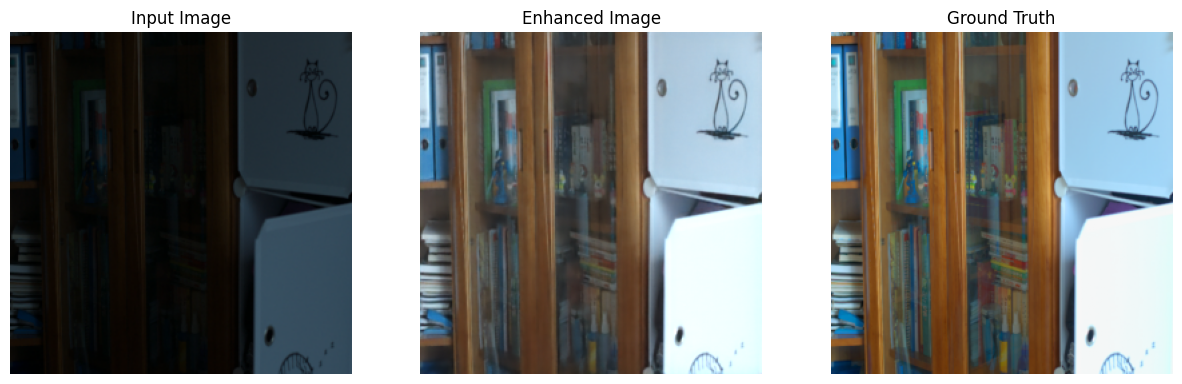

Image 1
PSNR : 25.16
SSIM : 0.9156
----------------------------------------


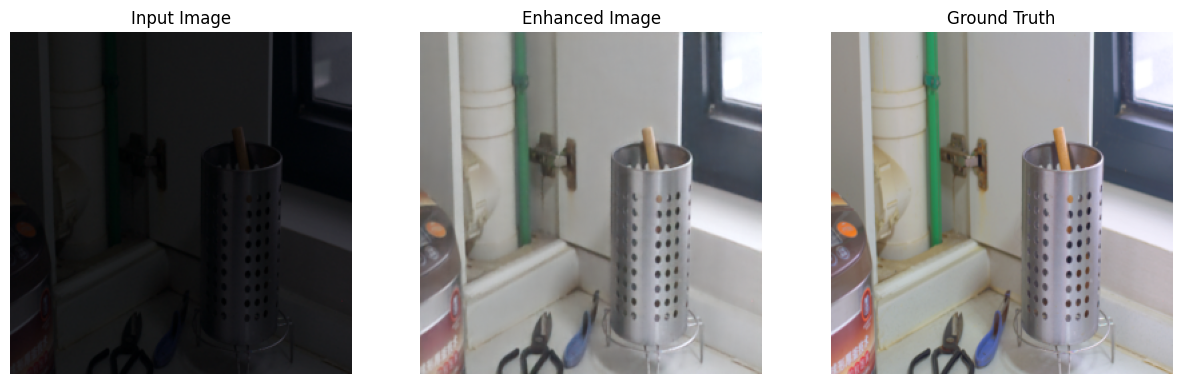

Image 2
PSNR : 30.45
SSIM : 0.9599
----------------------------------------


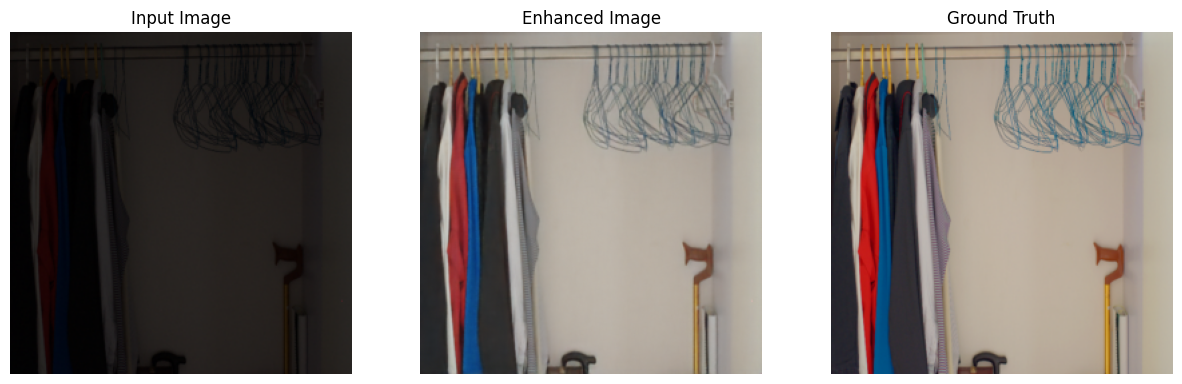

Image 3
PSNR : 29.44
SSIM : 0.9466
----------------------------------------


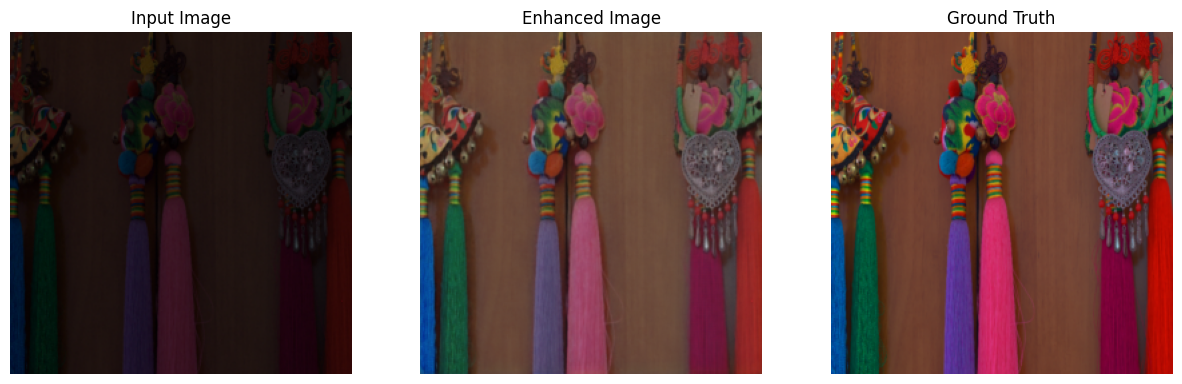

Image 4
PSNR : 24.37
SSIM : 0.8675
----------------------------------------


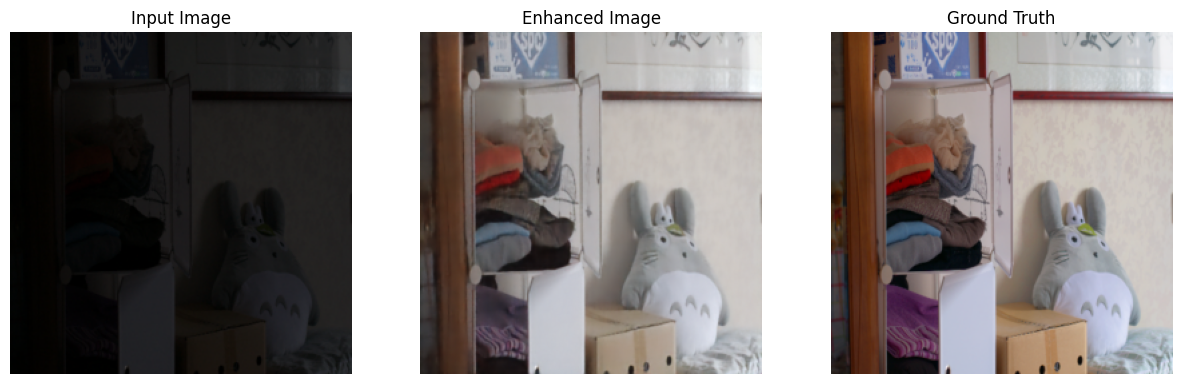

Image 5
PSNR : 29.38
SSIM : 0.9383
----------------------------------------


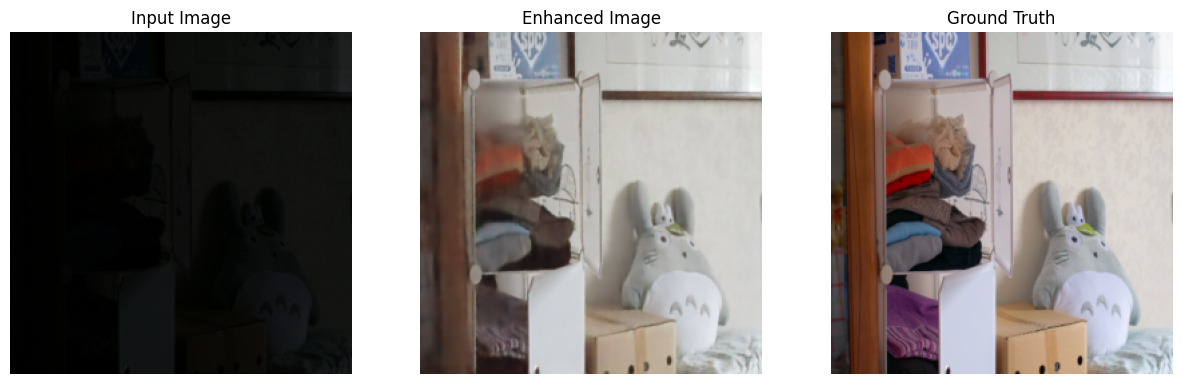

Image 6
PSNR : 27.21
SSIM : 0.9039
----------------------------------------


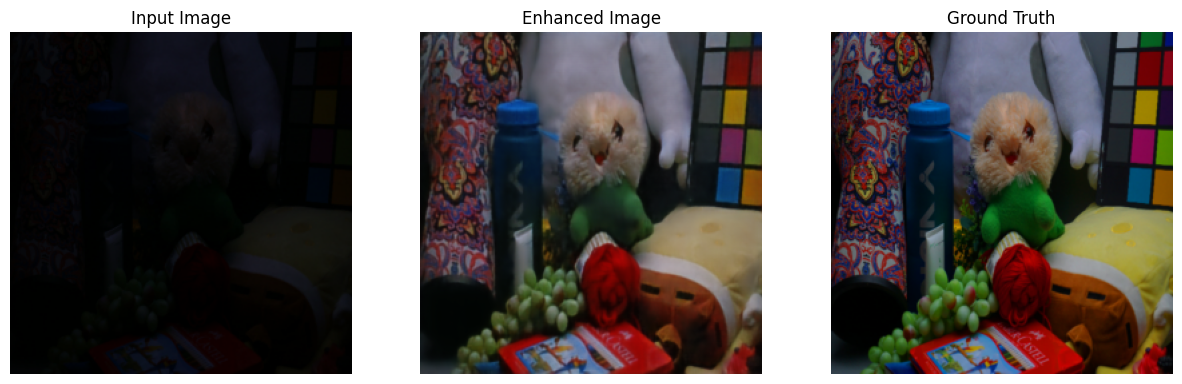

Image 7
PSNR : 25.71
SSIM : 0.7909
----------------------------------------


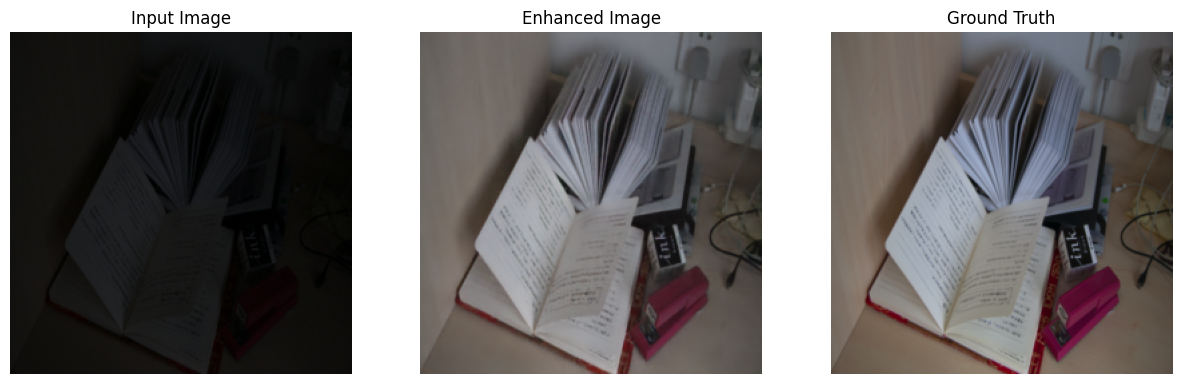

Image 8
PSNR : 31.18
SSIM : 0.9461
----------------------------------------


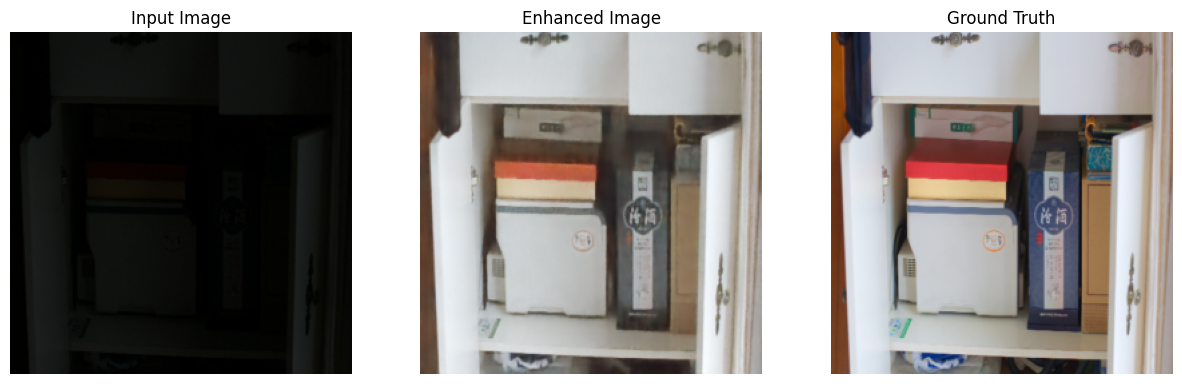

Image 9
PSNR : 27.14
SSIM : 0.9253
----------------------------------------


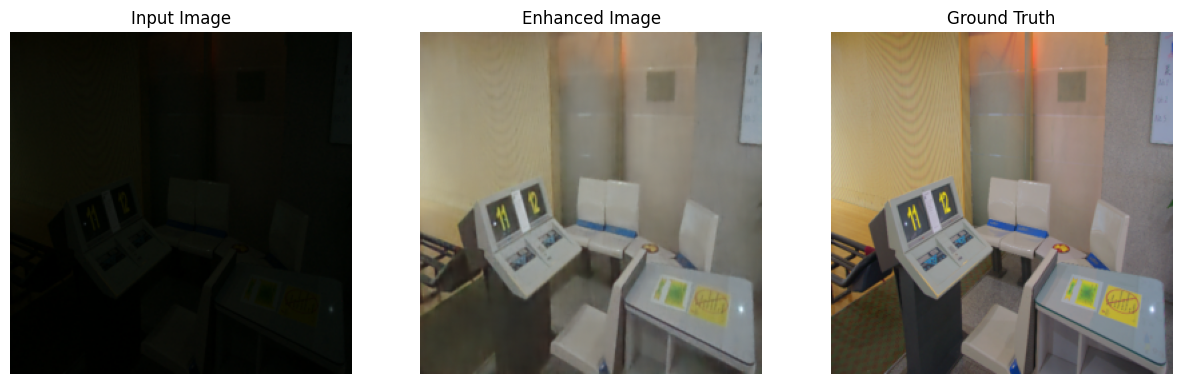

Image 10
PSNR : 28.21
SSIM : 0.9105
----------------------------------------


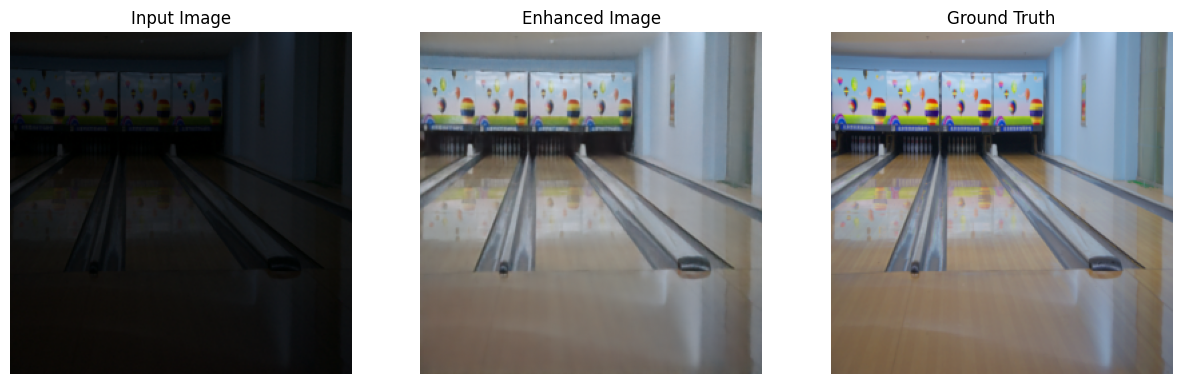

Image 11
PSNR : 28.18
SSIM : 0.9359
----------------------------------------


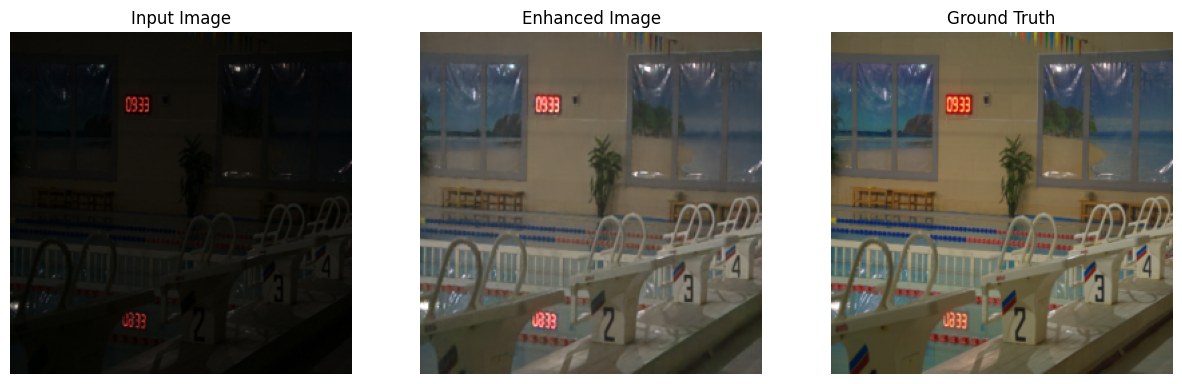

Image 12
PSNR : 28.34
SSIM : 0.9285
----------------------------------------


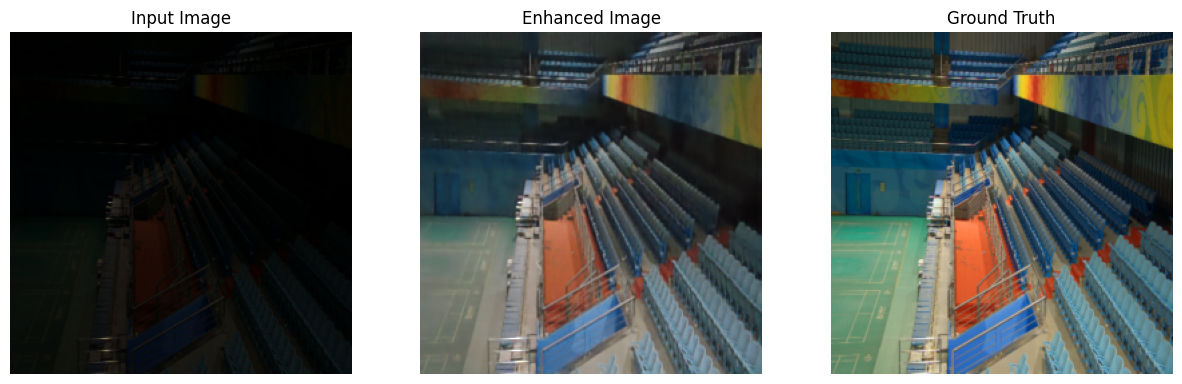

Image 13
PSNR : 23.10
SSIM : 0.8258
----------------------------------------


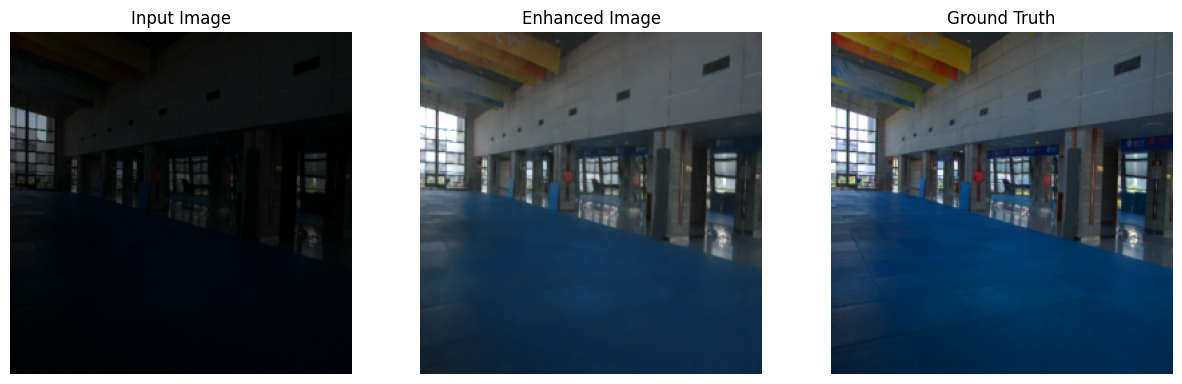

Image 14
PSNR : 28.05
SSIM : 0.8359
----------------------------------------


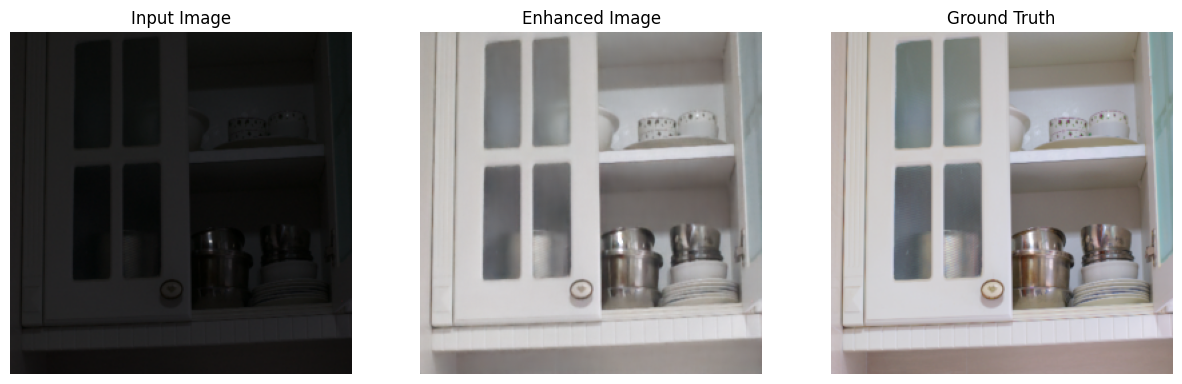

Image 15
PSNR : 33.69
SSIM : 0.9744
----------------------------------------

FINAL AVERAGE RESULTS
Average PSNR : 27.97
Average SSIM : 0.9070


In [20]:
from torchmetrics.image import PeakSignalNoiseRatio
from torchmetrics.image import StructuralSimilarityIndexMeasure

# ==============================
# METRICS
# ==============================

psnr_metric = PeakSignalNoiseRatio(data_range=1.0).to(device)
ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

# ==============================
# DETAILED TEST VISUALIZATION
# ==============================

model.eval()

total_psnr = 0
total_ssim = 0

with torch.no_grad():

    for idx, (low_img, high_img) in enumerate(test_loader):

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        # --------------------------------
        # MODEL OUTPUT
        # --------------------------------

        enhanced, _, _ = model(low_img)

        # --------------------------------
        # CLAMP OUTPUT
        # --------------------------------

        enhanced = torch.clamp(enhanced, 0, 1)

        # --------------------------------
        # CALCULATE METRICS
        # --------------------------------

        psnr_value = psnr_metric(enhanced, high_img).item()
        ssim_value = ssim_metric(enhanced, high_img).item()

        total_psnr += psnr_value
        total_ssim += ssim_value

        # --------------------------------
        # CONVERT TO NUMPY
        # --------------------------------

        low_np = low_img[0].clamp(0,1).permute(1, 2, 0).cpu().numpy()
        enhanced_np = enhanced[0].clamp(0,1).permute(1, 2, 0).cpu().numpy()
        high_np = high_img[0].clamp(0,1).permute(1, 2, 0).cpu().numpy()

        # --------------------------------
        # DISPLAY IMAGES
        # --------------------------------

        plt.figure(figsize=(15,5))

        # INPUT IMAGE
        plt.subplot(1,3,1)
        plt.imshow(low_np)
        plt.title("Input Image")
        plt.axis("off")

        # ENHANCED IMAGE
        plt.subplot(1,3,2)
        plt.imshow(enhanced_np)
        plt.title("Enhanced Image")
        plt.axis("off")

        # GROUND TRUTH
        plt.subplot(1,3,3)
        plt.imshow(high_np)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.show()

        # --------------------------------
        # PRINT INDIVIDUAL METRICS
        # --------------------------------

        print(f"Image {idx+1}")
        print(f"PSNR : {psnr_value:.2f}")
        print(f"SSIM : {ssim_value:.4f}")
        print("-" * 40)

# ==============================
# AVERAGE METRICS
# ==============================

avg_psnr = total_psnr / len(test_loader)
avg_ssim = total_ssim / len(test_loader)

print("\nFINAL AVERAGE RESULTS")
print(f"Average PSNR : {avg_psnr:.2f}")
print(f"Average SSIM : {avg_ssim:.4f}")

In [21]:
# ==============================
# SAVE ONLY ENHANCED IMAGES
# FOR IEEE PAPER RESULTS
# ==============================

import os
from torchvision.utils import save_image

# ==============================
# CREATE SAVE FOLDER
# ==============================

save_dir = "/kaggle/working/enhanced_results"

os.makedirs(save_dir, exist_ok=True)

# ==============================
# MODEL EVALUATION
# ==============================

model.eval()

total_psnr = 0
total_ssim = 0

with torch.no_grad():

    for idx, (low_img, high_img) in enumerate(test_loader):

        low_img = low_img.to(device)
        high_img = high_img.to(device)

        # --------------------------------
        # MODEL OUTPUT
        # --------------------------------

        enhanced, _, _ = model(low_img)

        # --------------------------------
        # CLAMP OUTPUT
        # --------------------------------

        enhanced = torch.clamp(enhanced, 0, 1)

        # --------------------------------
        # CALCULATE METRICS
        # --------------------------------

        psnr_value = psnr_metric(enhanced, high_img).item()
        ssim_value = ssim_metric(enhanced, high_img).item()

        total_psnr += psnr_value
        total_ssim += ssim_value

        # --------------------------------
        # SAVE ENHANCED IMAGE
        # --------------------------------

        save_path = os.path.join(
            save_dir,
            f"enhanced_{idx+1}.png"
        )

        save_image(enhanced, save_path)

        # --------------------------------
        # PRINT METRICS
        # --------------------------------

        print(f"Image {idx+1}")
        print(f"PSNR : {psnr_value:.2f}")
        print(f"SSIM : {ssim_value:.4f}")
        print(f"Saved : {save_path}")
        print("-" * 40)

# ==============================
# FINAL AVERAGE METRICS
# ==============================

avg_psnr = total_psnr / len(test_loader)
avg_ssim = total_ssim / len(test_loader)

print("\n================================")
print("FINAL AVERAGE RESULTS")
print("================================")
print(f"Average PSNR : {avg_psnr:.2f}")
print(f"Average SSIM : {avg_ssim:.4f}")

# ==============================
# DOWNLOAD ZIP FILE
# ==============================

import shutil

zip_path = "/kaggle/working/enhanced_results.zip"

shutil.make_archive(
    "/kaggle/working/enhanced_results",
    'zip',
    save_dir
)

print("\nZIP FILE CREATED")
print(zip_path)

Image 1
PSNR : 25.16
SSIM : 0.9156
Saved : /kaggle/working/enhanced_results/enhanced_1.png
----------------------------------------
Image 2
PSNR : 30.45
SSIM : 0.9599
Saved : /kaggle/working/enhanced_results/enhanced_2.png
----------------------------------------
Image 3
PSNR : 29.44
SSIM : 0.9466
Saved : /kaggle/working/enhanced_results/enhanced_3.png
----------------------------------------
Image 4
PSNR : 24.37
SSIM : 0.8675
Saved : /kaggle/working/enhanced_results/enhanced_4.png
----------------------------------------
Image 5
PSNR : 29.38
SSIM : 0.9383
Saved : /kaggle/working/enhanced_results/enhanced_5.png
----------------------------------------
Image 6
PSNR : 27.21
SSIM : 0.9039
Saved : /kaggle/working/enhanced_results/enhanced_6.png
----------------------------------------
Image 7
PSNR : 25.71
SSIM : 0.7909
Saved : /kaggle/working/enhanced_results/enhanced_7.png
----------------------------------------
Image 8
PSNR : 31.18
SSIM : 0.9461
Saved : /kaggle/working/enhanced_results/

In [26]:
import os

GT_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/high"
PRED_DIR = "/kaggle/working/enhanced_results"

matched = 0

for img_name in sorted(os.listdir(GT_DIR)):

    pred_name = "enhanced_" + img_name

    pred_path = os.path.join(
        PRED_DIR,
        pred_name
    )

    if os.path.exists(pred_path):
        matched += 1

print("Matched =", matched)

Matched = 1


In [27]:
print(sorted(os.listdir(GT_DIR)))
print(sorted(os.listdir(PRED_DIR)))

['1.png', '111.png', '146.png', '179.png', '22.png', '23.png', '493.png', '547.png', '55.png', '665.png', '669.png', '748.png', '778.png', '780.png', '79.png']
['enhanced_1.png', 'enhanced_10.png', 'enhanced_11.png', 'enhanced_12.png', 'enhanced_13.png', 'enhanced_14.png', 'enhanced_15.png', 'enhanced_2.png', 'enhanced_3.png', 'enhanced_4.png', 'enhanced_5.png', 'enhanced_6.png', 'enhanced_7.png', 'enhanced_8.png', 'enhanced_9.png']


In [31]:
!pip install -q lpips

import os
import cv2
import lpips
import torch
import numpy as np

GT_DIR = "/kaggle/input/datasets/soumikrakshit/lol-dataset/lol_dataset/eval15/high"
PRED_DIR = "/kaggle/working/enhanced_results"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

loss_fn = lpips.LPIPS(net='alex').to(device)

gt_files = sorted(os.listdir(GT_DIR))
pred_files = sorted(os.listdir(PRED_DIR))

scores = []

for gt_name, pred_name in zip(gt_files, pred_files):

    gt = cv2.imread(os.path.join(GT_DIR, gt_name))
    pred = cv2.imread(os.path.join(PRED_DIR, pred_name))

    gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)
    pred = cv2.cvtColor(pred, cv2.COLOR_BGR2RGB)

    gt = cv2.resize(gt, (pred.shape[1], pred.shape[0]))

    gt = torch.tensor(gt).float().permute(2,0,1).unsqueeze(0)
    pred = torch.tensor(pred).float().permute(2,0,1).unsqueeze(0)

    gt = (gt / 127.5) - 1
    pred = (pred / 127.5) - 1

    gt = gt.to(device)
    pred = pred.to(device)

    with torch.no_grad():
        score = loss_fn(pred, gt)

    scores.append(score.item())

print("Images Used :", len(scores))
print("Average LPIPS :", np.mean(scores))
print("Average LPIPS :", np.min(scores))

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Images Used : 15
Average LPIPS : 0.6914972141385078
Average LPIPS : 0.08043520897626877


In [32]:
# =====================================
# LOL-v2 REAL TEST EVALUATION
# COMPLETE SINGLE CELL
# =====================================

import glob
import torch


from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([

    transforms.Resize((256, 256)),

    transforms.ToTensor()

])

# =====================================
# LOL-v2 REAL TEST PATHS
# =====================================

LOLV2_TEST_LOW = "/kaggle/input/datasets/tanhyml/lol-v2-dataset/LOL-v2/Real_captured/Test/Low"

LOLV2_TEST_HIGH = "/kaggle/input/datasets/tanhyml/lol-v2-dataset/LOL-v2/Real_captured/Test/Normal"

# =====================================
# LOAD TEST FILES
# =====================================

lolv2_test_low_paths = sorted(
    glob.glob(LOLV2_TEST_LOW + "/*")
)

lolv2_test_high_paths = sorted(
    glob.glob(LOLV2_TEST_HIGH + "/*")
)

print("LOL-v2 Test Images :", len(lolv2_test_low_paths))

# =====================================
# CREATE TEST DATASET
# =====================================

lolv2_test_dataset = LowLightDataset(

    lolv2_test_low_paths,

    lolv2_test_high_paths,

    
)

# =====================================
# CREATE TEST LOADER
# =====================================

lolv2_test_loader = DataLoader(

    lolv2_test_dataset,

    batch_size=1,

    shuffle=False
)

# =====================================
# EVALUATION
# =====================================

model.eval()

total_psnr = 0

total_ssim = 0

with torch.no_grad():

    for low_img, high_img in lolv2_test_loader:

        low_img = low_img.to(device)

        high_img = high_img.to(device)

        # --------------------------------
        # MODEL OUTPUT
        # --------------------------------

        enhanced, _, _ = model(low_img)

        # --------------------------------
        # CLAMP OUTPUT
        # --------------------------------

        enhanced = torch.clamp(
            enhanced,
            0,
            1
        )

        # --------------------------------
        # CALCULATE METRICS
        # --------------------------------

        psnr_value = psnr_metric(
            enhanced,
            high_img
        ).item()

        ssim_value = ssim_metric(
            enhanced,
            high_img
        ).item()

        total_psnr += psnr_value

        total_ssim += ssim_value

# =====================================
# FINAL RESULTS
# =====================================

avg_psnr = total_psnr / len(lolv2_test_loader)

avg_ssim = total_ssim / len(lolv2_test_loader)

print("\n================================")

print("LOL-v2 REAL TEST RESULTS")

print("================================")

print(f"Average PSNR : {avg_psnr:.2f}")

print(f"Average SSIM : {avg_ssim:.4f}")

LOL-v2 Test Images : 100

LOL-v2 REAL TEST RESULTS
Average PSNR : 31.80
Average SSIM : 0.9398


In [31]:
# ==============================
# SAVE LOL-v2 ENHANCED IMAGES
# FOR IEEE PAPER RESULTS
# ==============================

import os
import shutil
import torch

from torchvision.utils import save_image

# ==============================
# CREATE SAVE FOLDER
# ==============================

save_dir = "/kaggle/working/lolv2_enhanced_results"

os.makedirs(save_dir, exist_ok=True)

# ==============================
# MODEL EVALUATION
# ==============================

model.eval()

total_psnr = 0

total_ssim = 0

with torch.no_grad():

    for idx, (low_img, high_img) in enumerate(lolv2_test_loader):

        low_img = low_img.to(device)

        high_img = high_img.to(device)

        # --------------------------------
        # MODEL OUTPUT
        # --------------------------------

        enhanced, _, _ = model(low_img)

        # --------------------------------
        # CLAMP OUTPUT
        # --------------------------------

        enhanced = torch.clamp(
            enhanced,
            0,
            1
        )

        # --------------------------------
        # CALCULATE METRICS
        # --------------------------------

        psnr_value = psnr_metric(
            enhanced,
            high_img
        ).item()

        ssim_value = ssim_metric(
            enhanced,
            high_img
        ).item()

        total_psnr += psnr_value

        total_ssim += ssim_value

        # --------------------------------
        # SAVE ENHANCED IMAGE
        # --------------------------------

        save_path = os.path.join(
            save_dir,
            f"enhanced_{idx+1}.png"
        )

        save_image(
            enhanced,
            save_path
        )

        # --------------------------------
        # PRINT RESULTS
        # --------------------------------

        print(f"Image {idx+1}")

        print(f"PSNR : {psnr_value:.2f}")

        print(f"SSIM : {ssim_value:.4f}")

        print(f"Saved : {save_path}")

        print("-" * 40)

# ==============================
# FINAL RESULTS
# ==============================

avg_psnr = total_psnr / len(lolv2_test_loader)

avg_ssim = total_ssim / len(lolv2_test_loader)

print("\n================================")

print("LOL-v2 FINAL RESULTS")

print("================================")

print(f"Average PSNR : {avg_psnr:.2f}")

print(f"Average SSIM : {avg_ssim:.4f}")

# ==============================
# CREATE ZIP FILE
# ==============================

zip_path = "/kaggle/working/lolv2_enhanced_results.zip"

shutil.make_archive(
    "/kaggle/working/lolv2_enhanced_results",
    'zip',
    save_dir
)

print("\nZIP FILE CREATED")

print(zip_path)

Image 1
PSNR : 29.45
SSIM : 0.9456
Saved : /kaggle/working/lolv2_enhanced_results/enhanced_1.png
----------------------------------------
Image 2
PSNR : 28.99
SSIM : 0.9328
Saved : /kaggle/working/lolv2_enhanced_results/enhanced_2.png
----------------------------------------
Image 3
PSNR : 28.20
SSIM : 0.9307
Saved : /kaggle/working/lolv2_enhanced_results/enhanced_3.png
----------------------------------------
Image 4
PSNR : 26.81
SSIM : 0.9279
Saved : /kaggle/working/lolv2_enhanced_results/enhanced_4.png
----------------------------------------
Image 5
PSNR : 29.12
SSIM : 0.9315
Saved : /kaggle/working/lolv2_enhanced_results/enhanced_5.png
----------------------------------------
Image 6
PSNR : 28.22
SSIM : 0.9317
Saved : /kaggle/working/lolv2_enhanced_results/enhanced_6.png
----------------------------------------
Image 7
PSNR : 28.25
SSIM : 0.9223
Saved : /kaggle/working/lolv2_enhanced_results/enhanced_7.png
----------------------------------------
Image 8
PSNR : 27.64
SSIM : 0.9181